In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [2]:
# 小盘：2.5-20 亿$
# 中盘：20-100 亿$
# 蓝筹：>100 亿$
# ---------------------------
# 1) 股票分组
# ---------------------------
AI_max = ["MSFT", "GOOGL", "META", "AMZN", "TSLA", "ORCL", "CRM", "ADBE"]
AI_mid = ["SNOW", "PLTR", "DDOG", "MDB", "U", "CRWD", "ZS", "NET"]
AI_min = ["AI", "BBAI", "SOUN", "VERI", "UPST", "CXAI"]

finance_max = ["JPM", "BAC", "WFC", "C", "GS", "MS", "AXP", "BLK", "SCHW"]
finance_mid = ["USB", "PNC", "TFC", "COF", "STT", "BK", "MTB", "FITB", "CFG"]
finance_min = ["HOOD", "SOFI", "AFRM", "LC", "MQ", "NU", "HIPO", "ROOT"]

encryption_max = ["COIN", "MSTR", "MARA", "RIOT", "CLSK", "HUT", "HIVE", "BITF"]
encryption_mid = ["CIFR", "WULF", "IREN", "BTBT", "CORZ", "BKKT", "BTDR"]
encryption_min = ["ANY", "ARBK", "ABTC", "GREE", "BTCS"]

semiconductor_max = ["NVDA", "AMD", "INTC", "AVGO", "QCOM", "TXN", "ADI", "MU", "NXPI", "TSM"]
semiconductor_mid = ["MCHP", "MPWR", "ON", "LRCX", "KLAC", "TER", "GFS"]
semiconductor_min = ["AEHR", "NVTS", "INDI", "LASR", "HIMX", "SMTC", "AMBA", "POWI"]

In [3]:
proxy = 'http://127.0.0.1:7890'  # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [ ]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"):
    os.environ.pop(v, None)

# 按照行业、盘子大小获取数据(每周)

In [4]:
# 展平去重
tickers = sorted(set(
    AI_max + AI_mid + AI_min +
    finance_max + finance_mid + finance_min +
    encryption_max + encryption_mid + encryption_min +
    semiconductor_max + semiconductor_mid + semiconductor_min
))

# 2025-11-20 当天：5分钟K线（end 右开，所以写到 11/21）
start_date = "2025-11-20"
end_date_exclusive = "2025-11-21"

data2 = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date_exclusive,
    interval="5m",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 提取 5分钟收盘价（优先 Close；没有就用 Adj Close）
if isinstance(data2.columns, pd.MultiIndex):
    if "Close" in data2.columns.get_level_values(1):
        px_5m = data2.xs("Close", axis=1, level=1)
    else:
        px_5m = data2.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data2.columns else "Adj Close"
    px_5m = data2[[col]].rename(columns={col: tickers[0]})

# 只保留 2025-11-20 当天的bar（稳妥起见再切一下）
px_5m = px_5m.loc["2025-11-20":"2025-11-20 23:59:59"]

# 5分钟“涨跌幅/收益率”：相邻两个5分钟bar的简单收益率
df_stock_minute = px_5m.pct_change()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\1655871154.py:38: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_stock_minute = px_5m.pct_change()


# 按照行业获取ETF涨跌幅数据（每分）

In [5]:
# ---------------------------
AI_ETF = ["QQQ", "AIQ", "BOTZ"]
FIN_ETF = ["XLF", "KRE", "PSCF"]
CRYP_ETF = ["IBIT", "BLOK", "WGMI"]
SEMI_ETF = ["SMH", "SOXX", "XSD"]

etfs = sorted(set(AI_ETF + FIN_ETF + CRYP_ETF + SEMI_ETF))

In [6]:
# 2025-11-20 当天：按 5 分钟获取 ETF 数据（end 右开，所以写到 11/21）
start_date = "2025-11-20"
end_date_exclusive = "2025-11-21"

data = yf.download(
    tickers=" ".join(etfs),
    start=start_date,
    end=end_date_exclusive,
    interval="5m",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
    # prepost=True,  # 如需盘前/盘后，取消注释
)

# 提取 5分钟 Close（若没有 Close 就退回 Adj Close）
if isinstance(data.columns, pd.MultiIndex):
    if "Close" in data.columns.get_level_values(1):
        px_5m = data.xs("Close", axis=1, level=1)
    else:
        px_5m = data.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data.columns else "Adj Close"
    px_5m = data[[col]].rename(columns={col: etfs[0]})

# 只保留 2025-11-20 当天（稳妥起见再切一下）
px_5m = px_5m.loc["2025-11-20":"2025-11-20 23:59:59"]

# 5分钟“涨跌幅/收益率”（相邻两根5分钟bar的简单收益率）
df_etf_minute = px_5m.pct_change()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\1675420079.py:31: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_etf_minute = px_5m.pct_change()


In [7]:
df_etf_minute

Ticker,BOTZ,QQQ,KRE,SMH,IBIT,PSCF,WGMI,XSD,BLOK,SOXX,AIQ,XLF
Datetime,,,,,,,,,,,,
2025-11-20 14:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-20 14:35:00+00:00,-0.001594,0.000720,-0.001995,-0.001924,-0.001931,NaN,-0.009331,0.001943,-0.004706,-0.002249,-0.001402,0.000574
2025-11-20 14:40:00+00:00,0.000145,0.000098,-0.001978,-0.001122,-0.001742,NaN,-0.002986,-0.006721,-0.004390,-0.002635,-0.001003,-0.001051
2025-11-20 14:45:00+00:00,-0.000290,0.000065,0.002147,-0.000778,-0.003005,NaN,0.001640,0.000485,0.000163,-0.000695,-0.000803,-0.000096
2025-11-20 14:50:00+00:00,-0.000058,0.001396,-0.002581,0.003026,0.002917,NaN,0.004688,0.000751,0.001024,0.002018,0.001105,-0.002488
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-20 20:35:00+00:00,-0.002709,-0.002753,-0.001588,-0.003897,-0.002137,NaN,-0.007953,-0.003259,-0.004646,-0.004325,-0.002579,-0.000877
2025-11-20 20:40:00+00:00,-0.000755,-0.000920,-0.001758,-0.001384,0.000204,NaN,-0.006617,-0.000444,-0.002065,-0.001249,-0.001475,-0.000975
2025-11-20 20:45:00+00:00,-0.001359,-0.002525,-0.001258,-0.002680,-0.000408,NaN,-0.007301,-0.002125,-0.002609,-0.002371,-0.002322,-0.001366


# 以分为单位，对每支股票涨跌幅可视化

In [8]:
# 个股分组
groups = {
    "AI": {
        "max": AI_max,
        "mid": AI_mid,
        "min": AI_min,
        "etf": ["QQQ", "AIQ", "BOTZ"]
    },
    "Finance": {
        "max": finance_max,
        "mid": finance_mid,
        "min": finance_min,
        "etf": ["XLF", "KRE", "PSCF"]
    },
    "Crypto": {
        "max": encryption_max,
        "mid": encryption_mid,
        "min": encryption_min,
        "etf": ["IBIT", "BLOK", "WGMI"]
    },
    "Semiconductor": {
        "max": semiconductor_max,
        "mid": semiconductor_mid,
        "min": semiconductor_min,
        "etf": ["SMH", "SOXX", "XSD"]
    }
}

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\2217243949.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


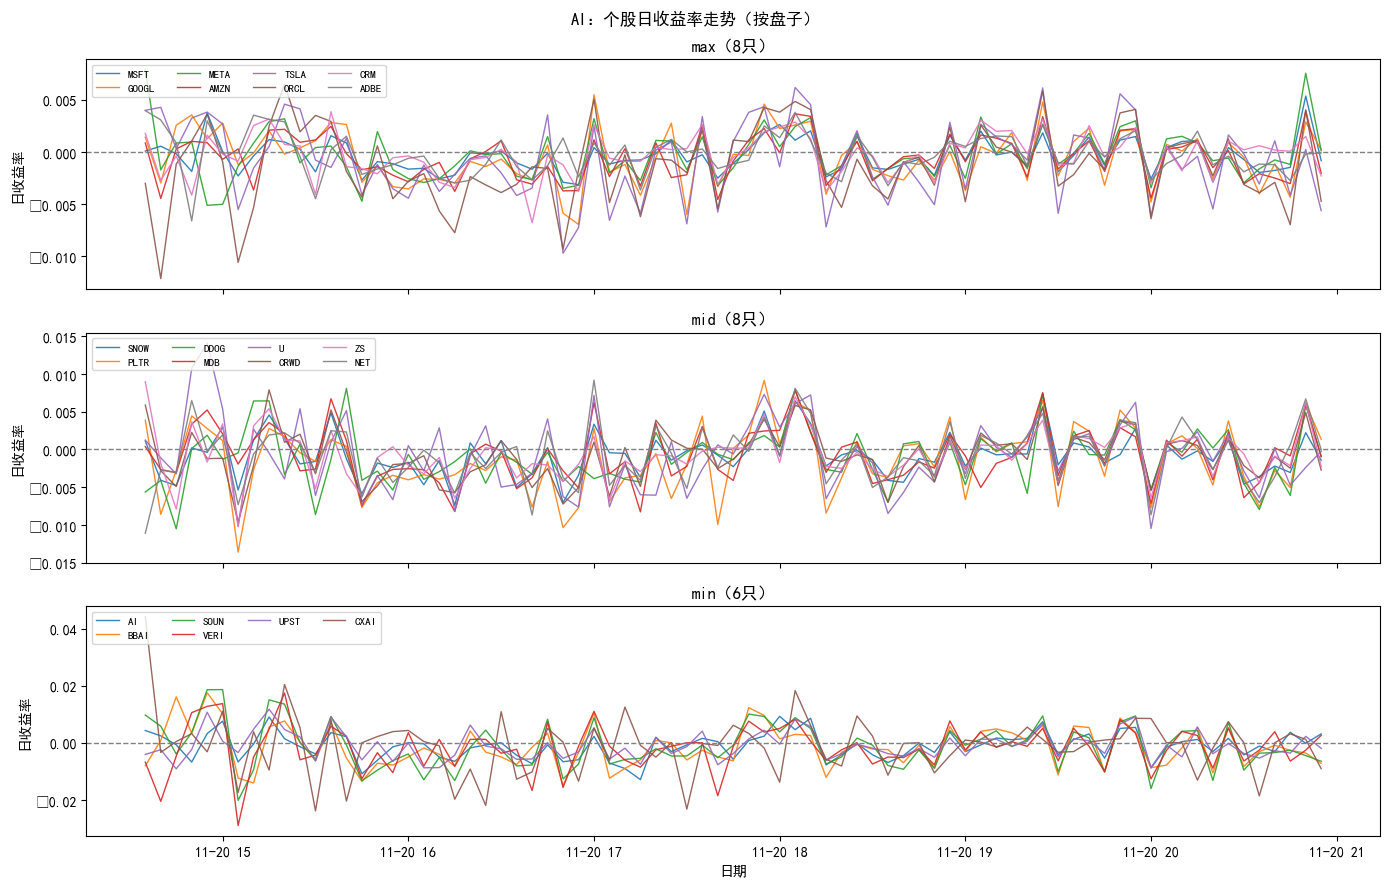

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\2217243949.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


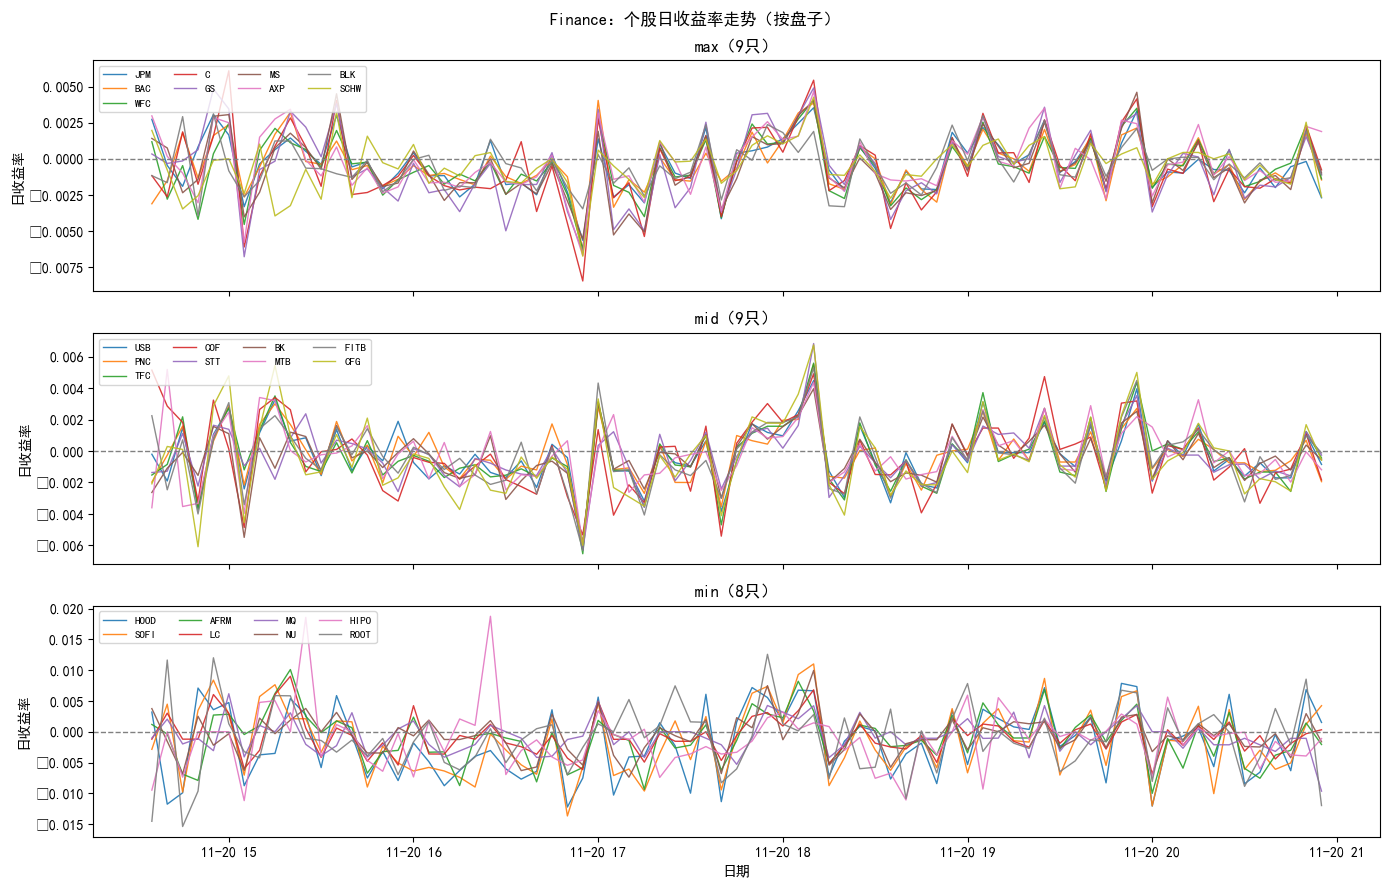

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\2217243949.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


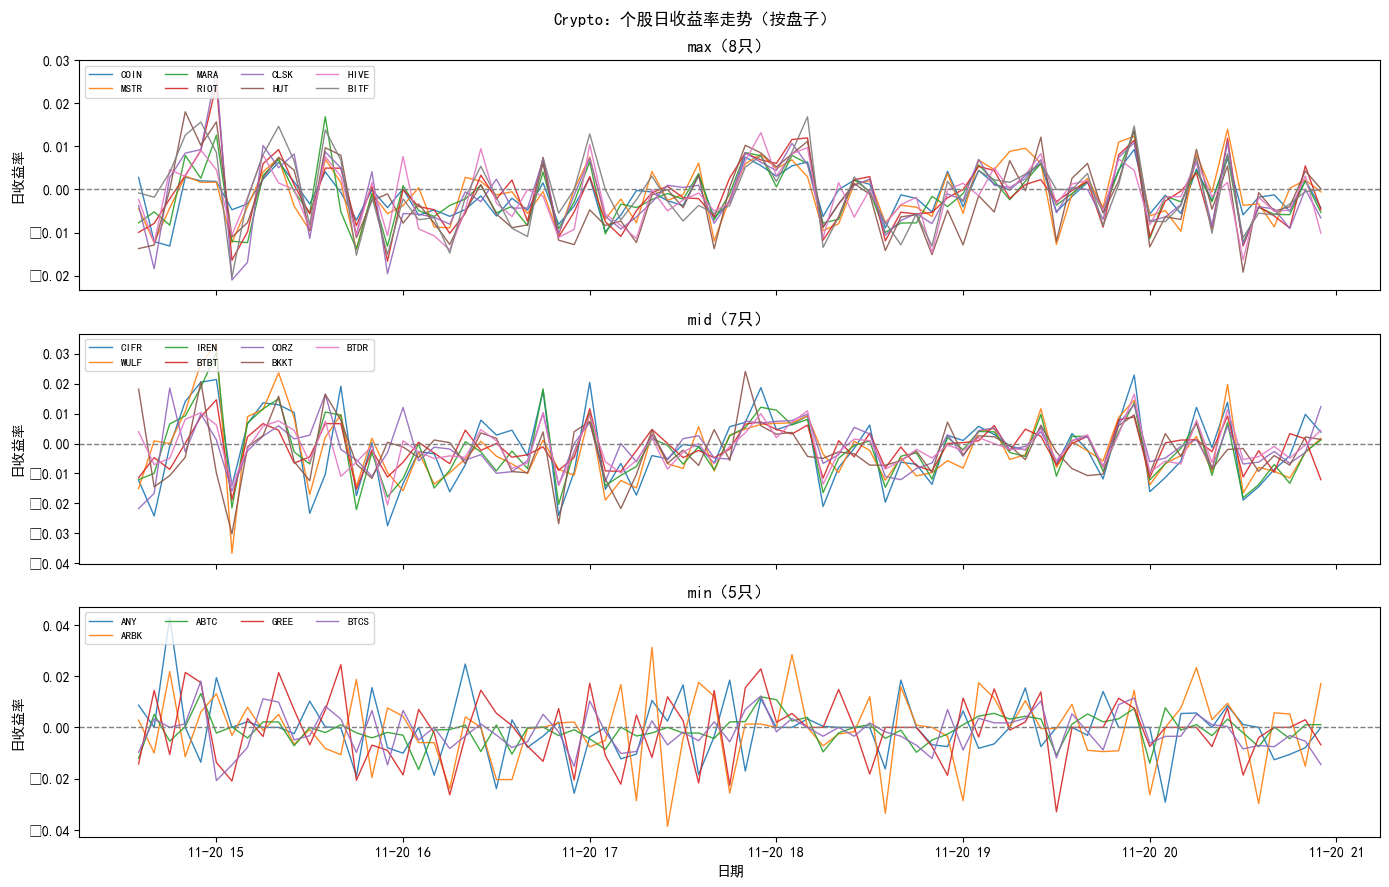

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26596\2217243949.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


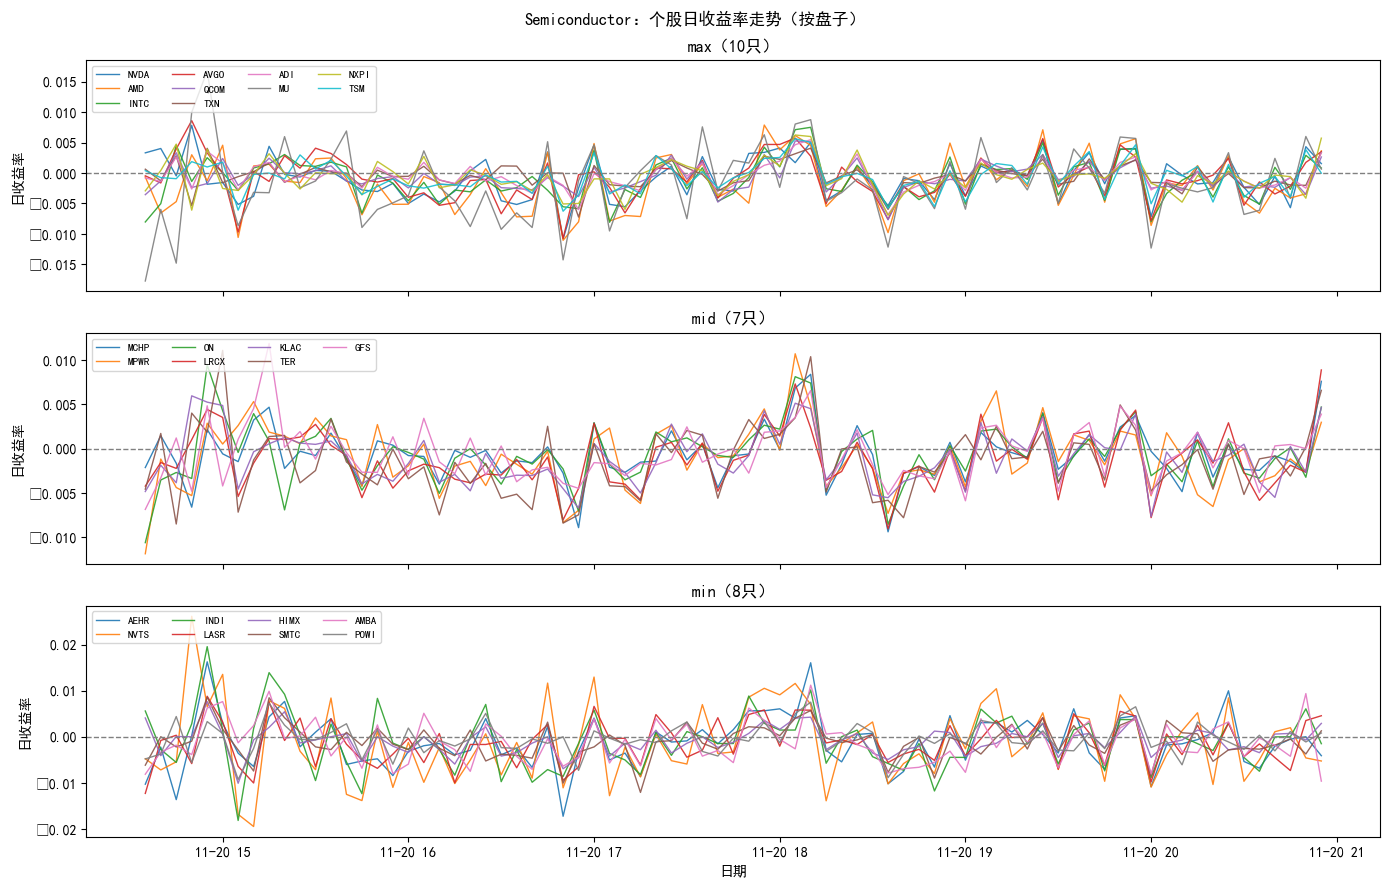

In [9]:
df = df_stock_minute.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# =========================
# 按行业 + 盘子：画每支股票“日收益率走势”
# 每个行业一张图，3 个子图分别是 max / mid / min
# =========================
for sector, cfg in groups.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{sector}：个股日收益率走势（按盘子）", y=0.98)

    for ax, size, stock_list in zip(
        axes,
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [s for s in stock_list if s in df.columns]
        if len(stock_cols) == 0:
            ax.text(0.5, 0.5, f"{size}: 无股票数据", transform=ax.transAxes,
                    ha="center", va="center")
            ax.set_axis_off()
            continue

        sub = df[stock_cols].dropna(how="all")

        # 线很多时不画 legend（避免太乱）；线少时画 legend
        if len(stock_cols) <= 20:
            for t in stock_cols:
                ax.plot(sub.index, sub[t], linewidth=1, alpha=0.9, label=t)
            ax.legend(fontsize=8, ncol=4, loc="upper left")
        else:
            ax.plot(sub.index, sub.values, linewidth=0.8, alpha=0.7)
            ax.text(0.99, 0.01, f"{len(stock_cols)} stocks (legend omitted)",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

        ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
        ax.set_title(f"{size}（{len(stock_cols)}只）")
        ax.set_ylabel("日收益率")

    axes[-1].set_xlabel("日期")
    plt.tight_layout()
    plt.show()